In [2]:
from datasets import load_dataset
import pandas as pd

C:\Users\zohre\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds = load_dataset("ParsiAI/digikala-sentiment-analysis")

In [4]:
ds["train"].to_csv(
"Digikala_train.csv",
index=False
)

ds["test"].to_csv(
"Digikala_test.csv",
index=False
)

Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 199.18ba/s]


222659

In [5]:
data_train=pd.read_csv('Digikala_train.csv')

data_train

,Text,Score,Suggestion
0,قیمت مناسب ولی صدا خیلی زیاد,60,2
1,دو سالی مشه که از دیجی کالا خریدم خیلی خوبه قد...,100,1
2,سلام دوستای عزیزم من دیروز این محصول رو خریدا...,80,1
3,تازه از دیجی کالا خریدم بیشتر از قابلیت متر که...,88,1
4,اگه هدفون ارزون میخوایید بخرید,60,2
...,...,...,...
2277,این دستگاه در عمل توان مخلوط ساده ای مانند شیر...,44,2
2278,سختی تمیز کاری محفظه جمع آوری خرده نان مصرف ب...,92,1
2279,اصلاراضی نبودم تازه خریدم که تیغه نمی چرخید خر...,60,3
2280,برای خریدش ذوق داشتم و کاربران هم تعریف شو داد...,36,3


In [6]:
d=data_train[data_train['Suggestion']==1]
del d['Score']
del d['Suggestion']
d.to_csv('train_1.csv',index=False)

In [7]:
d=data_train[data_train['Suggestion']==2]
del d['Score']
del d['Suggestion']
d.to_csv('train_2.csv',index=False)

In [8]:
d=data_train[data_train['Suggestion']==3]
del d['Score']
del d['Suggestion']
d.to_csv('train_3.csv',index=False)

# TRAIN

In [9]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer


In [10]:
data_train=pd.read_csv('Digikala_train.csv')

data_train

,Text,Score,Suggestion
0,قیمت مناسب ولی صدا خیلی زیاد,60,2
1,دو سالی مشه که از دیجی کالا خریدم خیلی خوبه قد...,100,1
2,سلام دوستای عزیزم من دیروز این محصول رو خریدا...,80,1
3,تازه از دیجی کالا خریدم بیشتر از قابلیت متر که...,88,1
4,اگه هدفون ارزون میخوایید بخرید,60,2
...,...,...,...
2277,این دستگاه در عمل توان مخلوط ساده ای مانند شیر...,44,2
2278,سختی تمیز کاری محفظه جمع آوری خرده نان مصرف ب...,92,1
2279,اصلاراضی نبودم تازه خریدم که تیغه نمی چرخید خر...,60,3
2280,برای خریدش ذوق داشتم و کاربران هم تعریف شو داد...,36,3


In [11]:
x=data_train['Text']
y=data_train['Suggestion']

In [ ]:
tf=TfidfVectorizer(ngram_range=(1,4),min_df=2,max_df=0.98,sublinear_tf=True)
x_transformed=tf.fit_transform(x)
x_transformed

<2282x262539 sparse matrix of type '<class 'numpy.float64'>'
	with 399107 stored elements in Compressed Sparse Row format>

In [33]:
model=LinearSVC()
model.fit(x_transformed,y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [ ]:
text='خوب'
text=tf.transform([text])

model.predict(text)

array([1], dtype=int64)

# TEST

In [15]:
data_test=pd.read_csv('Digikala_test.csv')
data_test

,Text,Score,Suggestion
0,فعلا در دوبار استفاده خیلی خوب بود البته یه کم...,92,1
1,سلام همه چیش خوبه فقط قدرت زیادی نداره یه وقتا...,52,2
2,من خریدم گلبهی رنگ پوستمه و کد اصالتش هم زدم ...,60,2
3,من قبلا دستگاه بلو ری داشتم ولی بعد 5سال که دا...,28,3
4,دیروز به دستم رسید ممنون از دیجی کالا والا ...,72,1
...,...,...,...
485,کلا مارک میبلین محصولات خوبی داره اگه اصل باش...,72,1
486,درود حدود دو سه ماهی است ازش استفاده میکنم بر...,84,2
487,خوشگله و قیمتش هم از بیرون کمتره و صفحه اش شفا...,92,1
488,از تلویزیون راضی هستم ولی اینکه بعد از 6 ماه پ...,88,1


In [34]:
x_test=data_test['Text']
x_test_transformed=tf.transform(x_test)

In [35]:
prediction=model.predict(x_test_transformed)
prediction

array([1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1,
       1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 1, 1, 1, 2,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [22]:
truth=data_test['Suggestion']
truth

0      1
1      2
2      2
3      3
4      1
      ..
485    1
486    2
487    1
488    1
489    2
Name: Suggestion, Length: 490, dtype: int64

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score

# NGRAM2

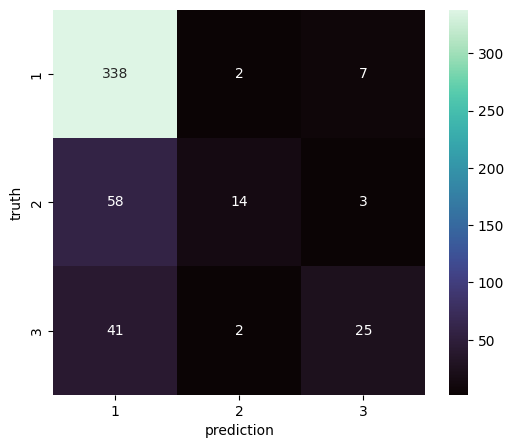

In [26]:
cm=confusion_matrix(truth,prediction,labels=[1,2,3])

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="mako",
            xticklabels=[1,2,3],
            yticklabels=[1,2,3])


plt.xlabel('prediction')
plt.ylabel('truth')
plt.show()

In [27]:
accuracy_score(truth,prediction)

0.7693877551020408

In [31]:
from sklearn.metrics import classification_report
print(classification_report(truth,prediction))

              precision    recall  f1-score   support

           1       0.77      0.97      0.86       347
           2       0.78      0.19      0.30        75
           3       0.71      0.37      0.49        68

    accuracy                           0.77       490
   macro avg       0.76      0.51      0.55       490
weighted avg       0.77      0.77      0.72       490



# NGRAM4

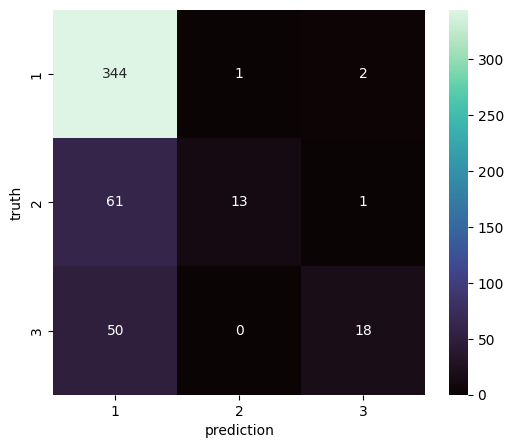

              precision    recall  f1-score   support

           1       0.76      0.99      0.86       347
           2       0.93      0.17      0.29        75
           3       0.86      0.26      0.40        68

    accuracy                           0.77       490
   macro avg       0.85      0.48      0.52       490
weighted avg       0.80      0.77      0.71       490



In [36]:
cm=confusion_matrix(truth,prediction,labels=[1,2,3])

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="mako",
            xticklabels=[1,2,3],
            yticklabels=[1,2,3])


plt.xlabel('prediction')
plt.ylabel('truth')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(truth,prediction))